First we do a principal component analysis to reduce the dimension of the bundles data


TEST A : PCA puis residualisation

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from neurostatx.io.loader import DatasetLoader
from neurostatx.utils.preprocessing import merge_dataframes

from scipy import stats
from statsmodels.regression.linear_model import OLS

from sklearn.impute import KNNImputer  
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [2]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
data_filtered_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/CCA/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/CCA/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Load ping data
ping_ori = pd.read_excel(f"{data_filtered_dir}/ping_data_filtered_for_bundles.xlsx")

# Load bundles
bundles_ori = pd.read_excel(f"{data_filtered_dir}/bundles_data_filtered_for_ping.xlsx")

In [4]:
# convertir en numérique
measure_cols = bundles_ori.columns[3:]
bundles_ori[measure_cols] = bundles_ori[measure_cols].apply(pd.to_numeric, errors="coerce")
bundles_scaled_tot = bundles_ori.copy()

# Standardiser les donnees des bundles avec mean=0 et std=1 pour les colonnes de mesures
bundles_scaled_tot[measure_cols] = pd.DataFrame(StandardScaler().fit_transform(bundles_ori[measure_cols]))

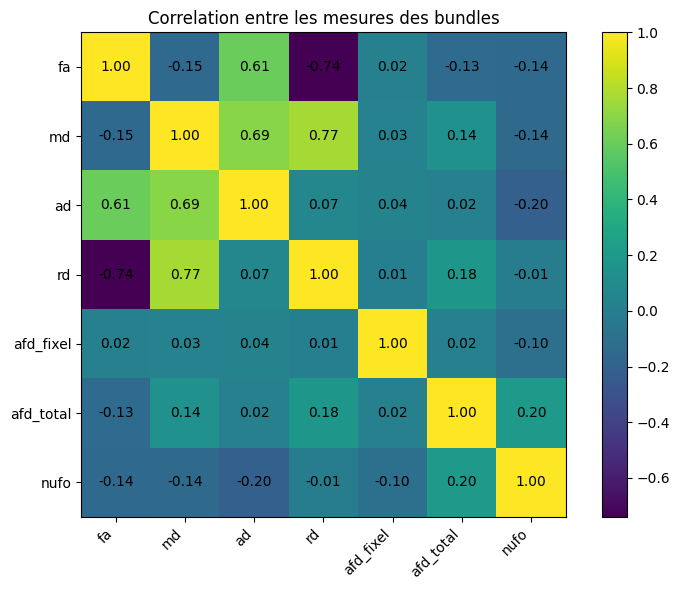

In [5]:
# Matrice de corrélation pour les mesures des bundles
measure_cols = bundles_scaled_tot[["fa", "md", "ad", "rd", "afd_fixel", "afd_total", "nufo"]].columns
corr_matrix = bundles_scaled_tot[measure_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, interpolation="nearest")
plt.colorbar(im)

ax.set_xticks(range(len(measure_cols)))
ax.set_yticks(range(len(measure_cols)))
ax.set_xticklabels(measure_cols, rotation=45, ha="right")
ax.set_yticklabels(measure_cols)

for i in range(len(measure_cols)):
    for j in range(len(measure_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

ax.set_title("Correlation entre les mesures des bundles")
plt.tight_layout()
plt.show()

In [6]:
# Performing PCA 
selected_cols = ["fa","md", "rd", "ad", "nufo", "afd_fixel", "afd_total"]
bundles_scaled = bundles_scaled_tot[["sample", "bundle"] + selected_cols]

pca = PCA()
principal_components = pca.fit_transform(bundles_scaled[selected_cols])
principal_df = pd.DataFrame(data=principal_components, columns=[f"PC{i+1}" for i in range(principal_components.shape[1])])

# Garder les composantes avec eigenvalues >= 1
n_keep = np.sum(pca.explained_variance_ >= 1)
if n_keep == 0:
    n_keep = 1

principal_df = pd.DataFrame(
    data=principal_components[:, :n_keep],
    columns=[f"PC{i+1}" for i in range(n_keep)],
      index=bundles_scaled.index)

# Ajouter les colonnes "sample" et "bundle" au DataFrame des scores PCA
principal_df.insert(0, "sample", bundles_scaled["sample"].values)
principal_df.insert(1, "bundle", bundles_scaled.iloc[:, 1].values)

# variance expliquée
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_))],
    "Eigenvalue": pca.explained_variance_,
    "Explained_variance_ratio": pca.explained_variance_ratio_,
    "Cumulative_variance": pca.explained_variance_ratio_.cumsum()
})
# loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

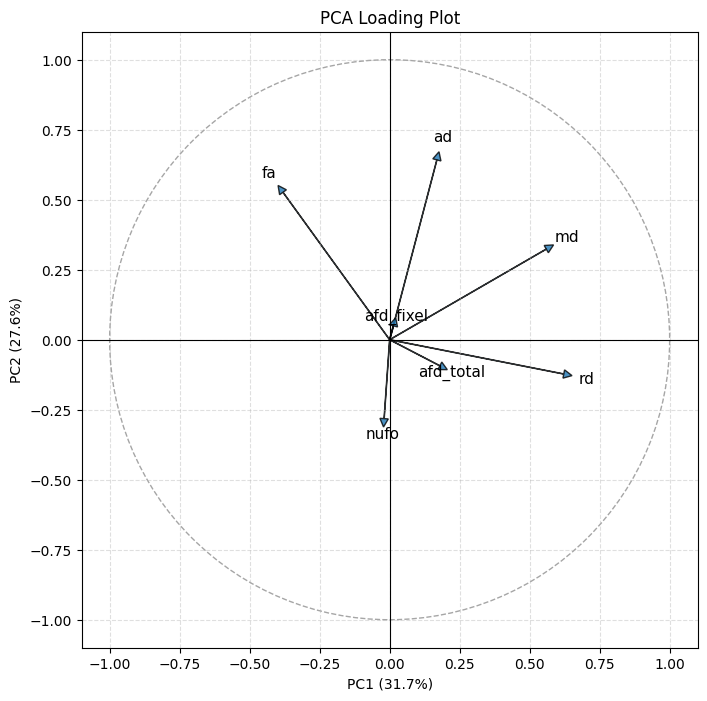

In [7]:
# Extraire les loadings de PC1 et PC2
pc1 = pca_loadings["PC1"]
pc2 = pca_loadings["PC2"]

# Figure
plt.figure(figsize=(8, 8))

# Cercle de corrélation simple
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.7)
plt.gca().add_artist(circle)

# Tracer les vecteurs
for var in selected_cols:
    x = pc1[var]
    y = pc2[var]
    
    plt.arrow(
        0, 0, x, y,
        head_width=0.03,
        head_length=0.03,
        length_includes_head=True,
        alpha=0.8
    )
    plt.text(
        x * 1.08,
        y * 1.08,
        var,
        fontsize=11,
        ha='center',
        va='center'
    )

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Labels avec variance expliquée
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.xlabel(f"PC1 ({var_pc1:.1f}%)")
plt.ylabel(f"PC2 ({var_pc2:.1f}%)")
plt.title("PCA Loading Plot")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

In [8]:
# Pivoter et reformuler les lignes et colonnes pour les pc
sample_col = principal_df.columns[0]
bundle_col = principal_df.columns[1]
pc_cols = principal_df.columns[2:]

# pivot : une ligne par sample, colonnes = bundle x pc
bundles_pivot = principal_df.pivot(index=sample_col, columns=bundle_col, values=pc_cols)

In [9]:
# Filtrer les colonnes avec 20% ou plus de valeurs manquantes
missing_pct = bundles_pivot.isna().mean() * 100
cols_to_keep = missing_pct[missing_pct < 20].index
bundles_20 = bundles_pivot.loc[:, cols_to_keep].copy()

# colonnes supprimées
cols_removed = missing_pct[missing_pct >= 20].index

print("Nombre de colonnes supprimées :", len(cols_removed))
print("Colonnes supprimées :")
print(list(cols_removed))

Nombre de colonnes supprimées : 12
Colonnes supprimées :
[('PC1', 'AC'), ('PC1', 'CG_L_curve'), ('PC1', 'CG_R_curve'), ('PC1', 'PC'), ('PC2', 'AC'), ('PC2', 'CG_L_curve'), ('PC2', 'CG_R_curve'), ('PC2', 'PC'), ('PC3', 'AC'), ('PC3', 'CG_L_curve'), ('PC3', 'CG_R_curve'), ('PC3', 'PC')]


In [10]:
# Préparer les mêmes masques pour tous les k
rng = np.random.default_rng(42)

# prendre seulement un sous-ensemble de colonnes pour choisir k
n_test_cols = min(20, bundles_20.shape[1])
test_cols = rng.choice(bundles_20.columns, size=n_test_cols, replace=False)

X_test = bundles_20[test_cols].copy()

# créer un seul plan de masquage
mask_fraction = 0.20
masked_positions = []

X_masked = X_test.copy()

for col in test_cols:
    observed_idx = X_test.index[X_test[col].notna()]
    if len(observed_idx) < 10:
        continue

    n_mask = max(2, int(len(observed_idx) * mask_fraction))
    chosen_idx = rng.choice(observed_idx, size=n_mask, replace=False)

    for idx in chosen_idx:
        masked_positions.append((idx, col))

    X_masked.loc[chosen_idx, col] = np.nan

In [11]:
# tester quelques k 
k_values = [5, 7, 10, 15, 20, 25, 30, 40, 50, 60, 70]
results = []

for k in k_values:
    imputer = KNNImputer(
        n_neighbors=k,
        weights="distance",
        metric="nan_euclidean"
    )

    X_imputed = pd.DataFrame(
        imputer.fit_transform(X_masked),
        index=X_masked.index,
        columns=X_masked.columns
    )

    true_vals = np.array([X_test.loc[idx, col] for idx, col in masked_positions], dtype=float)
    pred_vals = np.array([X_imputed.loc[idx, col] for idx, col in masked_positions], dtype=float)

    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    results.append({"k": k, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)


In [12]:
# Afficher les résultats et choisir le meilleur k
print(results_df[["k", "rmse"]])
best_k = results_df.loc[0, "k"]
print("Best k:", best_k)

     k      rmse
0   20  1.105766
1   25  1.106012
2   30  1.108057
3   40  1.108572
4   50  1.109518
5   15  1.112251
6   10  1.114196
7   60  1.114921
8   70  1.117453
9    7  1.120954
10   5  1.132285
Best k: 20


In [13]:
# Impute the missing values in bundles using the best KNN imputer
imputer = KNNImputer(
    n_neighbors=best_k,
    weights="distance",
    metric="nan_euclidean"
)

bundles_imputed = pd.DataFrame(
    imputer.fit_transform(bundles_20),
    columns=bundles_20.columns,
    index=bundles_20.index
)

In [ ]:
# À SUPPRIMER
# convertir les colonnes tuple en vrai MultiIndex
bundles_imputed.columns = pd.MultiIndex.from_tuples(
    bundles_imputed.columns,
    names=["measure", "bundle"]
)

# revenir au format long
bundles_unpivot = (
    bundles_imputed
    .stack(level="bundle")
    .reset_index()
)

# remettre les colonnes dans l'ordre voulu
selected_cols = ["fa", "md", "ad", "rd", "afd_fixel", "afd_total", "nufo"]
bundles_unpivot = bundles_unpivot.rename(columns={"bundle": "bundle"})
bundles_unpivot = bundles_unpivot[["sample", "bundle"] + selected_cols]

In [ ]:
# A SUPPRIMER
# Performing PCA 
selected_cols = ["fa", "md", "ad", "rd", "afd_fixel", "afd_total", "nufo"]
pca = PCA()
principal_components = pca.fit_transform(bundles_unpivot[selected_cols])
principal_df = pd.DataFrame(data=principal_components, columns=[f"PC{i+1}" for i in range(principal_components.shape[1])])

# Garder les composantes avec eigenvalues >= 1
n_keep = np.sum(pca.explained_variance_ >= 1)
if n_keep == 0:
    n_keep = 1

principal_df = pd.DataFrame(
    data=principal_components[:, :n_keep],
    columns=[f"PC{i+1}" for i in range(n_keep)],
      index=bundles_unpivot.index)

# Ajouter les colonnes "sample" et "bundle" au DataFrame des scores PCA
principal_df.insert(0, "sample", bundles_unpivot["sample"].values)
principal_df.insert(1, "bundle", bundles_unpivot.iloc[:, 1].values)

# variance expliquée
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_))],
    "Eigenvalue": pca.explained_variance_,
    "Explained_variance_ratio": pca.explained_variance_ratio_,
    "Cumulative_variance": pca.explained_variance_ratio_.cumsum()
})
# loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

In [14]:
# Gerer la colonne/index sample pour le merge
ping_for_merge = ping_ori.copy()
ping_for_merge = ping_for_merge.rename(columns={"Sample": "sample"})
ping_for_merge["sample"] = ping_for_merge["sample"].astype(str)

bundles_for_merge = bundles_imputed.reset_index()
bundles_for_merge["sample"] = bundles_for_merge["sample"].astype(str)

# Verifier l'ordre des samples
(ping_for_merge["sample"].values == bundles_for_merge["sample"].values).all()

np.True_

In [15]:
# Merge
ping_and_bundles = merge_dataframes({"ping" : ping_for_merge, "bundles" : bundles_for_merge}, index="sample")

In [19]:
# Residualisation des bundles pour age, sex, handedness, etchnicity
# Separate the covariates and the variates data
covars = ping_and_bundles[["Sex", "AgeMonths", "Ethnicity", "Handedness"]].copy()
vars = ping_and_bundles.iloc[:, 14:].copy()

covars = sm.add_constant(covars)

# Instantiating an empty dataframe to store the results
residuals = pd.DataFrame(index=ping_and_bundles.index)

# Running a linear regression model for eact variate
for var in vars.columns:
    model = OLS(vars[var], covars)
    results = model.fit()
    residuals[var] = results.resid

C:\Users\Rosalie\AppData\Local\Temp\ipykernel_22252\1063603305.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  residuals[var] = results.resid
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_22252\1063603305.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  residuals[var] = results.resid
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_22252\1063603305.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all co

In [20]:
# Merging the residuals with the original data
ping_bundles_resid = pd.concat([ping_and_bundles.drop(columns=vars), residuals], axis=1)

# Saving the residualized data.
ping_bundles_resid.to_excel(f"{output_dir}/ping_bundles_residualized.xlsx", index=True, header=True)

In [21]:
# Verifier que la residiualisation a bien fonctionné
X = sm.add_constant(ping_and_bundles[["AgeMonths", "Sex", "Ethnicity", "Handedness"]])

for col in residuals.columns:
    model = sm.OLS(residuals[col], X).fit()
    print(f"\n{col}")
    print(model.summary().tables[1])
# Coef environ 0 = pas de relation entre les covariables et les variables d'intérêt, ce qui est le but de la residualisation.
# P values élevés (1) = pas de relation significative entre les covariables et les variables d'intérêt, ce qui est également le but de la residualisation.


('PC1', 'AF_L')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.663e-16      0.247   1.08e-15      1.000      -0.486       0.486
AgeMonths   1.736e-15      0.001   2.06e-12      1.000      -0.002       0.002
Sex         1.363e-15      0.073   1.87e-14      1.000      -0.143       0.143
Ethnicity  -2.637e-16      0.022   -1.2e-14      1.000      -0.043       0.043
Handedness  2.838e-16      0.097   2.93e-15      1.000      -0.190       0.190

('PC1', 'AF_R')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -6.852e-17      0.245   -2.8e-16      1.000      -0.481       0.481
AgeMonths   1.778e-15      0.001   2.13e-12      1.000      -0.002       0.002
Sex         1.416e-15      0.072   1.96e-14      1.000      -0.142       0.142
Ethnicity   -2.58e

CCA

In [22]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)

X = ping_bundles_resid.iloc[:, 14:]
X.index = ping_bundles_resid.index

Y = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X_c, Y_c = cca.fit_transform(X, Y)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X_c[:, i], Y_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")

Dimension canonique 1 : r = 0.667
Dimension canonique 2 : r = 0.575
Dimension canonique 3 : r = 0.546


In [23]:
# Voir le poids des faisceaux
bundles_weights = pd.DataFrame(
    cca.x_weights_,
    index=X.columns,
    columns=[f"CCA{i+1}" for i in range(cca.x_weights_.shape[1])]
)

bundles_weights.sort_values("CCA1", key=lambda s: abs(s), ascending=False)

,CCA1,CCA2,CCA3
"(PC3, PYT_L_Brainstem)",0.340531,-0.216937,0.081521
"(PC3, PYT_L)",-0.310646,0.255792,0.025105
"(PC2, FPT_R_Brainstem)",0.248921,0.009963,0.092524
"(PC2, POPT_R)",0.229404,0.082429,0.013215
"(PC3, PYT_R_Brainstem)",0.227529,-0.202931,-0.052208
...,...,...,...
"(PC2, CC_Fr_1)",0.002198,-0.009414,0.036350
"(PC2, SCP_L)",0.002046,0.004797,-0.013793
"(PC2, SLF_L)",0.001773,0.028613,0.037575
"(PC3, ICP_R)",-0.001057,0.061309,0.009653


In [24]:
# Voir le poids des variables cognitives
cog_weights = pd.DataFrame(
    cca.y_weights_,
    index=Y.columns,
    columns=[f"CCA{i+1}" for i in range(cca.y_weights_.shape[1])]
)

cog_weights.sort_values("CCA1", key=lambda s: abs(s), ascending=False)

,CCA1,CCA2,CCA3
MEM,-0.781299,0.216720,-0.585324
VA,-0.513446,-0.756375,0.405302
EFPS,0.354888,-0.617194,-0.702229


In [25]:
# Calculer les loadings des faisceaux pour la première dimension canonique 
brain_scores_1 = X_c[:, 0]

brain_loadings_1 = pd.Series(
    [np.corrcoef(X.iloc[:, j], brain_scores_1)[0, 1] for j in range(X.shape[1])],
    index=X.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

brain_loadings_1

(PC1, CC_Fr_1)            -0.164641
(PC3, SLF_L)              -0.158700
(PC3, FX_L)               -0.148591
(PC3, CC_Pr_Po)           -0.139962
(PC2, UF_L)               -0.139869
                             ...   
(PC1, CG_R)               -0.002264
(PC1, IFOF_L)              0.001975
(PC2, SLF_L)              -0.001599
(PC3, POPT_R_Brainstem)    0.000366
(PC2, CG_L_An)            -0.000118
Name: loading_CCA1, Length: 141, dtype: float64

In [26]:
#  Calculer les loadings des variables cognitives pour la première dimension canonique
cog_scores_1 = Y_c[:, 0]

cog_loadings_1 = pd.Series(
    [np.corrcoef(Y.iloc[:, j], cog_scores_1)[0, 1] for j in range(Y.shape[1])],
    index=Y.columns,
    name="loading_CCA1"
).sort_values(key=lambda s: abs(s), ascending=False)

cog_loadings_1

MEM    -0.919794
VA     -0.888768
EFPS   -0.313589
Name: loading_CCA1, dtype: float64

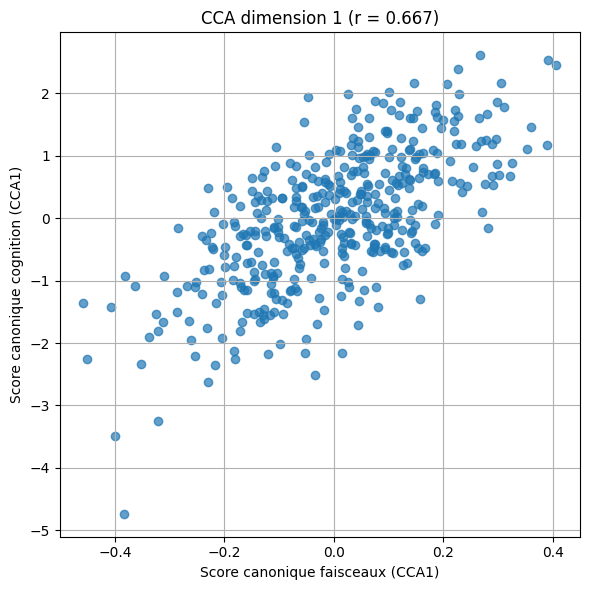

In [27]:
# Visualiser les scores canoniques pour la première dimension
plt.figure(figsize=(6, 6))
plt.scatter(X_c[:, 0], Y_c[:, 0], alpha=0.7)
plt.xlabel("Score canonique faisceaux (CCA1)")
plt.ylabel("Score canonique cognition (CCA1)")
plt.title(f"CCA dimension 1 (r = {canonical_corrs[0]:.3f})")
plt.grid(True)
plt.tight_layout()
plt.show()